# Inspection of variables after Full Selection

**_run with dfs created with the full selection_**

This notebook inspects the selected events after the full event selection 

In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [72]:
save_fig = True

today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "selected_events-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/selected_events-20260326


# Load dfs

In [73]:
dfs = get_ana_dfs(option="selected_events")

mc_evt_df     = dfs["mc"]
mc_hdr_df     = dfs["mc_hdr"]
data_evt_df   = dfs["data"]
data_hdr_df   = dfs["data_hdr"]
intime_evt_df = dfs["intime"]
intime_hdr_df = dfs["intime_hdr"]
dirt_evt_df   = dfs["dirt"]
dirt_hdr_df   = dfs["dirt_hdr"]

pot_label     = dfs["pot_label"]

Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ac, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ad, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ae, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag af, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ag, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histpotdf_0', '/split']
Reading file with tag ah, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/split']
Reading file with tag ai, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/split']
Reading file with tag aj, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/split']
Reading file with tag ak, mc_n_split: 1
Keys: ['/evt_

/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/files_config.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/files_config.py:180: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  intime_evt_df["gates_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/anal

In [74]:
import pickle

def get_syst_unc(var_config):
    date_str = "20260220"
    mcstat_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/mcstat_syst_dict.npz", allow_pickle=True)
    mcstat_syst =dict(mcstat_syst)[var_config.var_save_name].item()['MCstat']['cov_frac']

    g4_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/g4_syst_dict.npz", allow_pickle=True)
    g4_syst =dict(g4_syst)[var_config.var_save_name].item()['G4']['cov_frac']

    flux_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/flux_syst_dict.npz", allow_pickle=True)
    flux_syst =dict(flux_syst)[var_config.var_save_name].item()['flux']['cov_frac']

    date_str = "20260222"
    cosmics_syst = np.load(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-{date_str}/cosmics_syst_dict.npz", allow_pickle=True)
    cosmics_syst =dict(cosmics_syst)[var_config.var_save_name].item()['Cosmics']['cov_frac']

    date_str = "20260219"
    genie_syst = pickle.load(open(f"/exp/sbnd/data/users/munjung/plots/numucc1p0pi/cov_mat_dict-{date_str}.pkl", "rb"))
    genie_syst = genie_syst[var_config.var_save_name]['genie'] 

    # detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
    # detvar_syst = detvar_syst[var_config.var_save_name]['detvar']

    # detvar_syst = pickle.load(open("/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_10/nevts/det_unc_dict-20260216.pkl", "rb"))
    # detvar_syst = np.sqrt(detvar_syst[var_config.var_save_name]['ccal']**2 \
    #     + detvar_syst[var_config.var_save_name]['alpha']**2 \
    #     + detvar_syst[var_config.var_save_name]['beta']**2 \
    #     + detvar_syst[var_config.var_save_name]['R']**2) / 2.


    # flat uncertainties
    pot_frac_unc = 0.02
    ntargets_frac_unc = 0.01

    # flat uncertainties
    frac_uncert_total = np.zeros(len(var_config.bin_centers))
    cov_total = np.zeros((len(var_config.bin_centers), len(var_config.bin_centers)))
    systs      = [mcstat_syst, genie_syst, flux_syst, g4_syst, cosmics_syst]
    for syst in systs:
        cov_total += syst
        syst_uncert = np.sqrt(np.diag(syst))
        frac_uncert_total += syst_uncert ** 2

    flat_systs = [pot_frac_unc, ntargets_frac_unc]
    for syst in flat_systs:
        cov_total += np.diag(syst * np.ones(len(var_config.bin_centers)) ** 2)
        syst_uncert = syst * np.ones(len(var_config.bin_centers))
        frac_uncert_total += syst_uncert ** 2

    # frac_uncert_total += detvar_syst ** 2

    frac_uncert_total = np.sqrt(frac_uncert_total)
    # syst = frac_uncert_total

    return cov_total, frac_uncert_total

# Distribution of Selected Events

In [75]:
var_config = VariableConfig.list_all_configs(print_summary=False)

Available VariableConfig options:
  all_events          
  chi2_mu             
  chi2_proton         
  mcs_range_diff      
  muon_direction      
  muon_direction_phi  
  muon_direction_x    
  muon_direction_y    
  muon_momentum       
  muon_momentum_hybrid
  muon_momentum_mcs   
  n_trks              
  neutrino_energy     
  nu_score            
  opening_angle       
  proton_direction    
  proton_direction_phi
  proton_direction_x  
  proton_direction_y  
  proton_momentum     
  tki_del_Tp          
  tki_del_Tp_x        
  tki_del_Tp_y        
  tki_del_alpha       
  tki_del_p           
  tki_del_phi         
  track_score         
  trk_len             
  vertex_x            
  vertex_y            
  vertex_z            
  vtx_dist            


In [77]:
mc_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], mc_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
mc_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(mc_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], mc_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

data_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
data_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(data_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], data_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

intime_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(intime_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], intime_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
intime_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(intime_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], intime_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

# dirt_evt_df[('mu', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(dirt_evt_df['mu', 'pfp', 'trk', 'dir', 'x', '', ''], dirt_evt_df['mu', 'pfp', 'trk', 'dir', 'y', '', '']))
# dirt_evt_df[('p', 'pfp', 'trk', 'phi', '', '', '')] = np.degrees(np.arctan2(dirt_evt_df['p', 'pfp', 'trk', 'dir', 'x', '', ''], dirt_evt_df['p', 'pfp', 'trk', 'dir', 'y', '', '']))

In [131]:
eps = 1e-8
ratio = True
approval = "internal"
textloc = [0.03, 0.55]
ax_ylim_ratio = 1.9

data_vs_mc_plotter = partial(
    overlay_hists,
    mc_df=mc_evt_df,
    data_df=data_evt_df,
    intime_df=intime_evt_df,
    dirt_df = None,
    ax_ylim_ratio=ax_ylim_ratio,
    ratio=ratio,
    textloc=textloc,
    approval=approval,
    save_fig=save_fig, 
)

No dirt cosmics provided


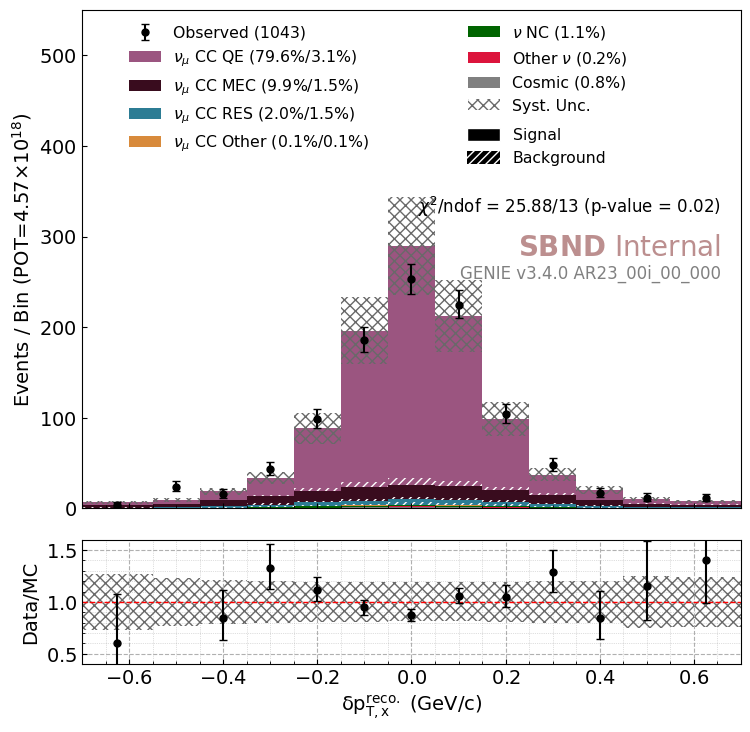

No dirt cosmics provided


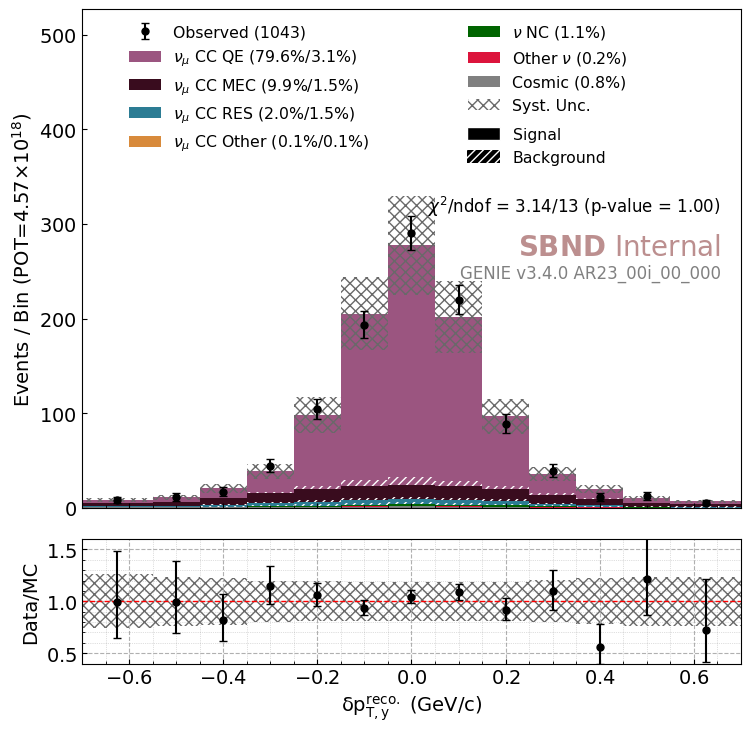

No dirt cosmics provided


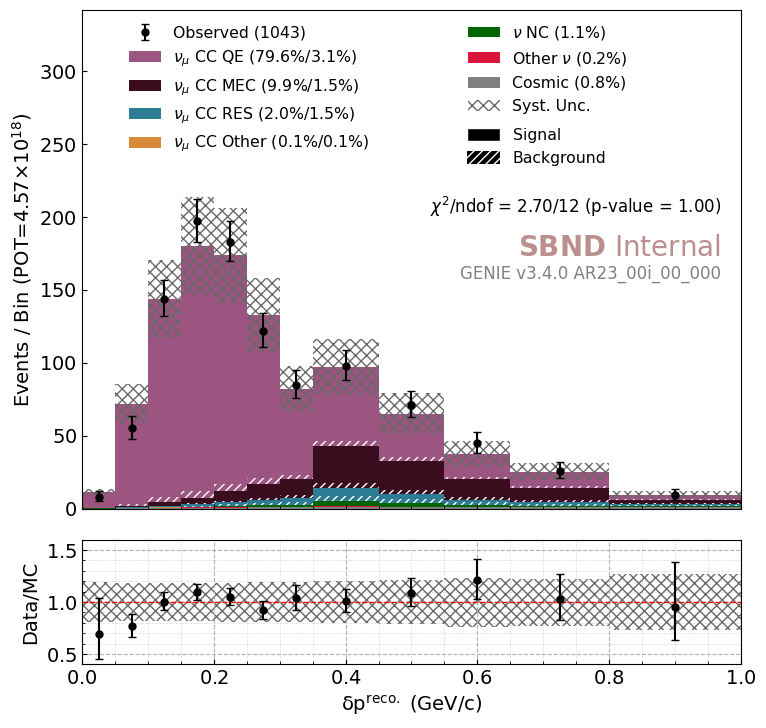

No dirt cosmics provided


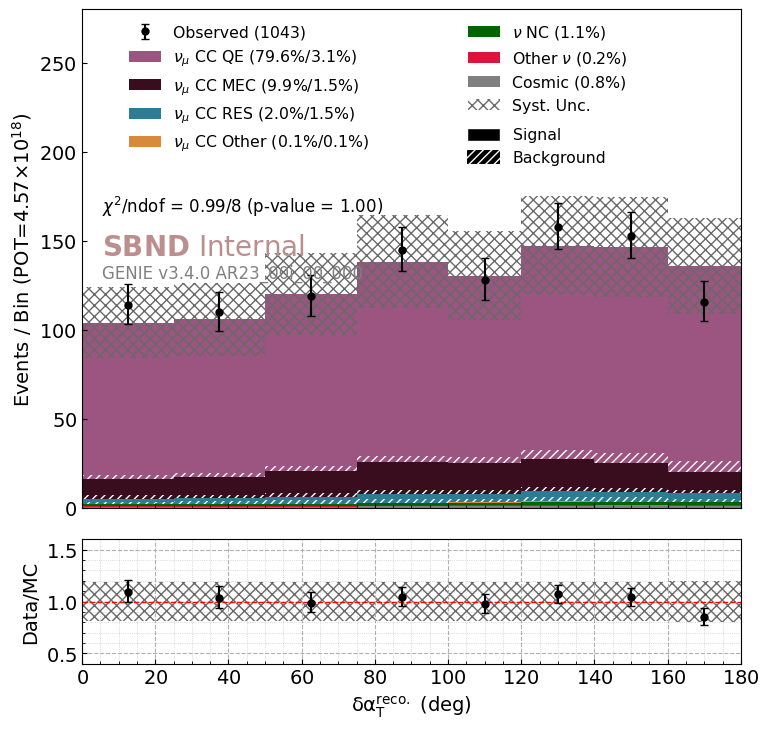

No dirt cosmics provided


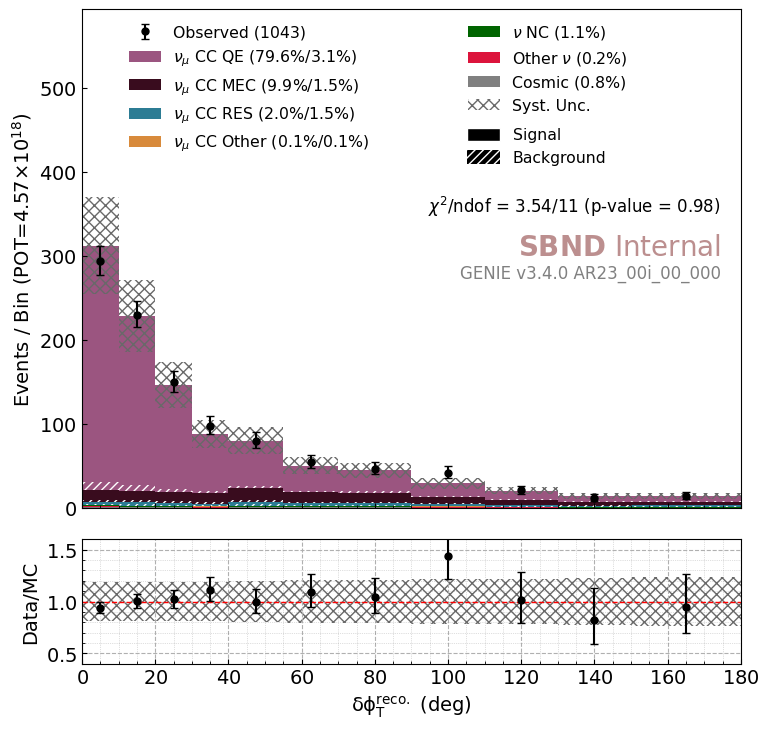

In [133]:
var_configs = [
    # VariableConfig.all_events(),
    # VariableConfig.muon_momentum(),
    # VariableConfig.muon_direction(),
    # VariableConfig.proton_momentum(),
    # VariableConfig.proton_direction(),
    # VariableConfig.tki_del_Tp(),
    VariableConfig.tki_del_Tp_x(),
    VariableConfig.tki_del_Tp_y(),
    VariableConfig.tki_del_p(),
    VariableConfig.tki_del_alpha(),
    VariableConfig.tki_del_phi(),
    ]

for var_config in var_configs:

    cov, frac_uncert = get_syst_unc(var_config)
    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

    # for breakdown_type in ["topology", "genie", "genie_sb"]:
    for breakdown_type in ["genie_sb"]:
        ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=cov,
                                textchi2=True,
                                save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

No dirt cosmics provided
no syst provided


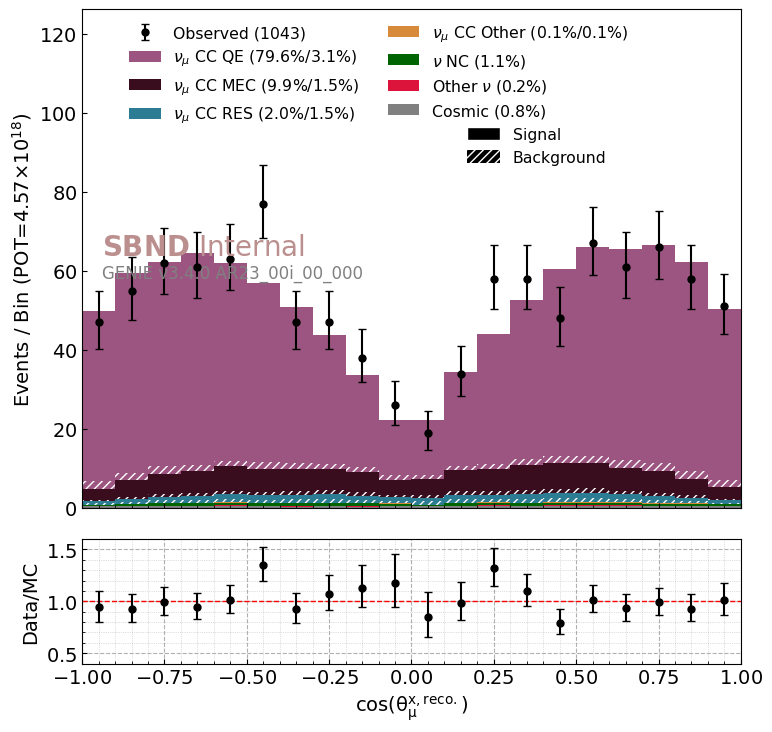

No dirt cosmics provided
no syst provided


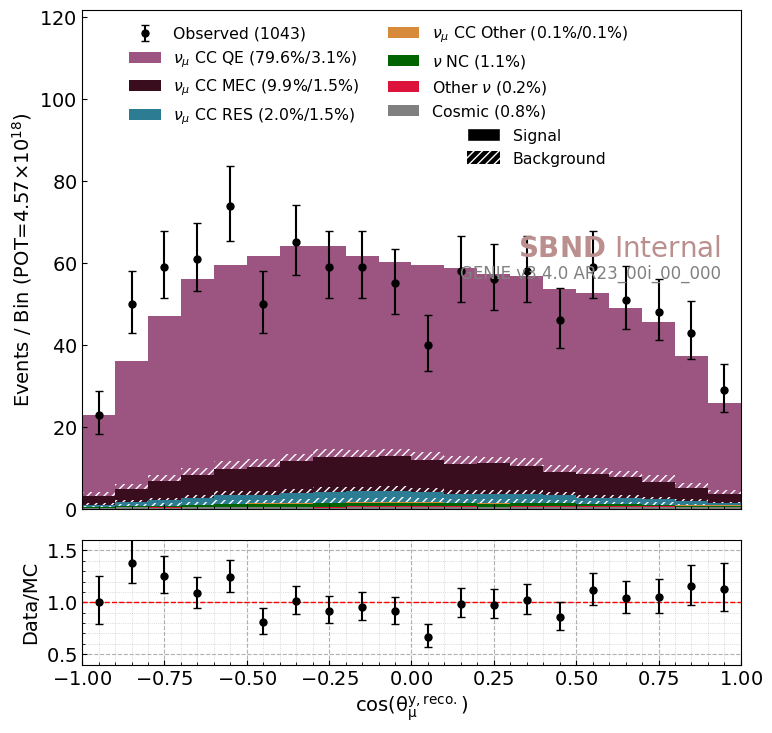

No dirt cosmics provided
no syst provided


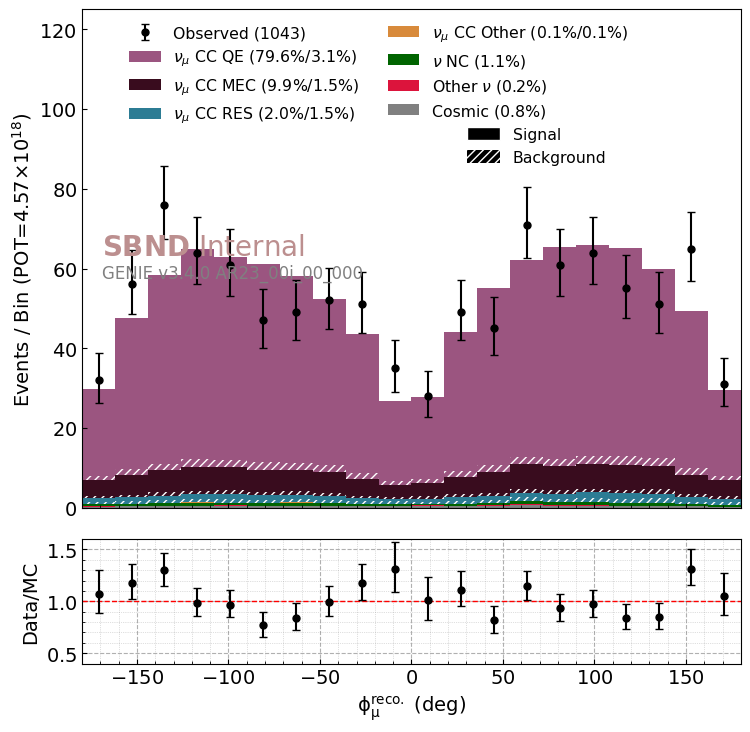

No dirt cosmics provided
no syst provided


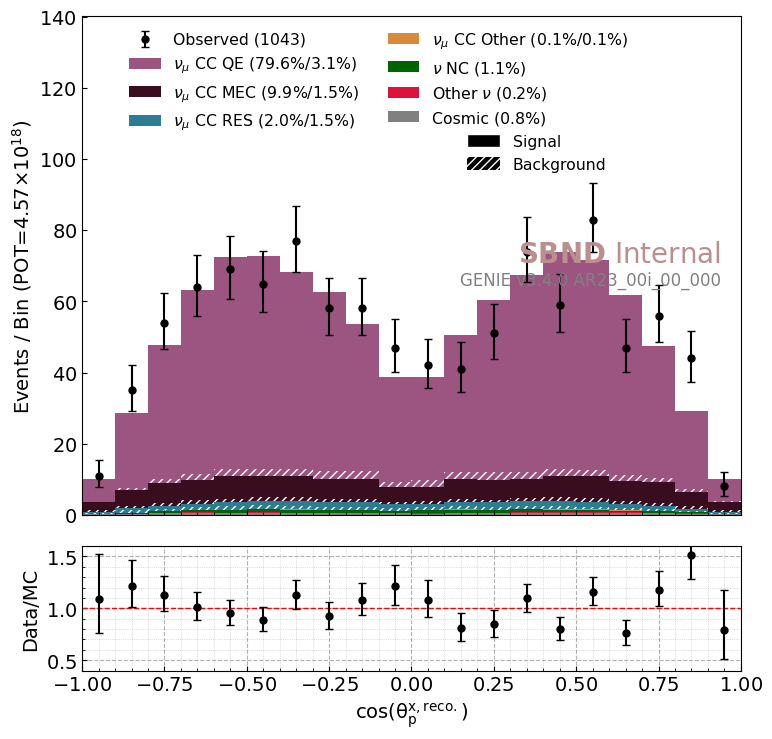

No dirt cosmics provided
no syst provided


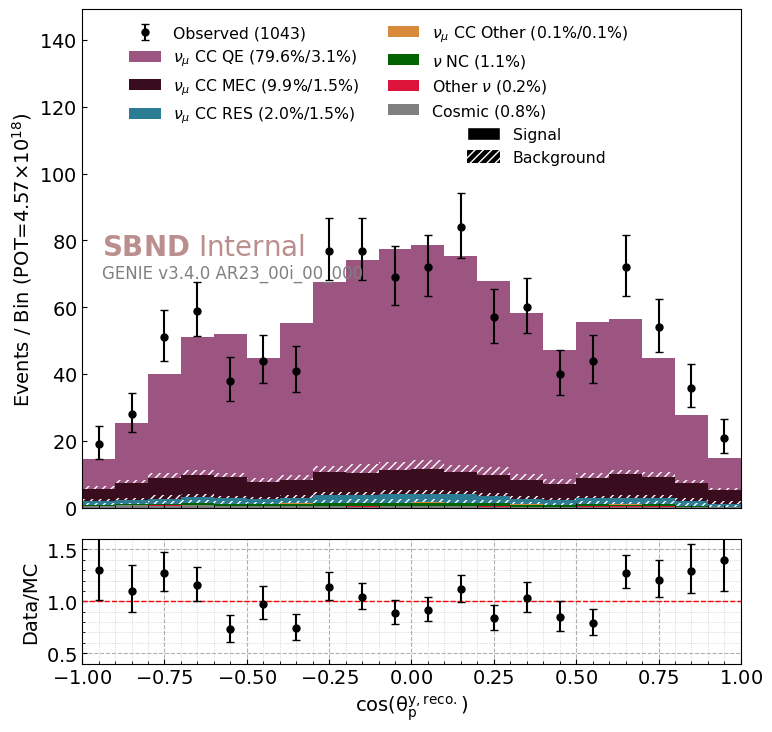

No dirt cosmics provided
no syst provided


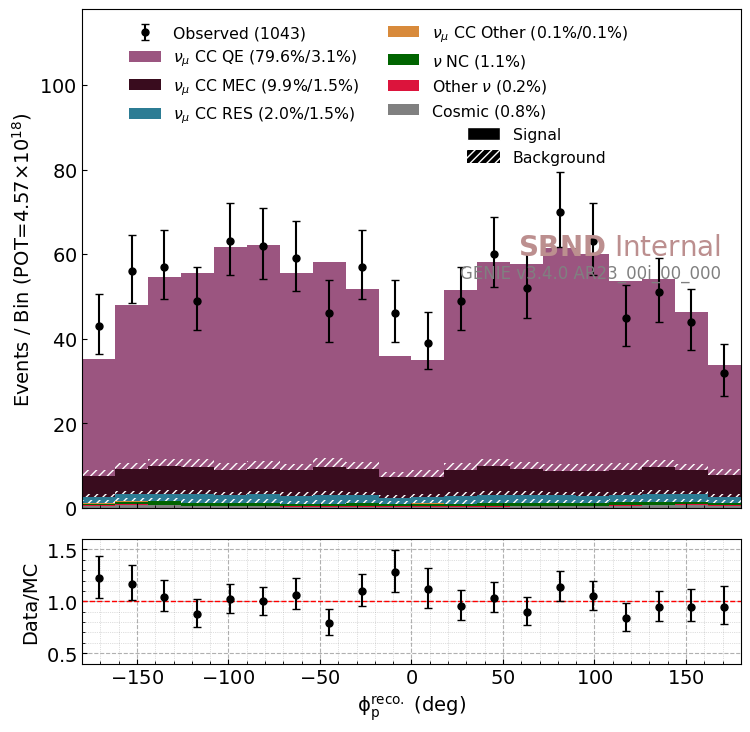

No dirt cosmics provided


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:610: RuntimeWarning: invalid value encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:611: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(data_ratio, nan=-999.)
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:612: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)


no syst provided


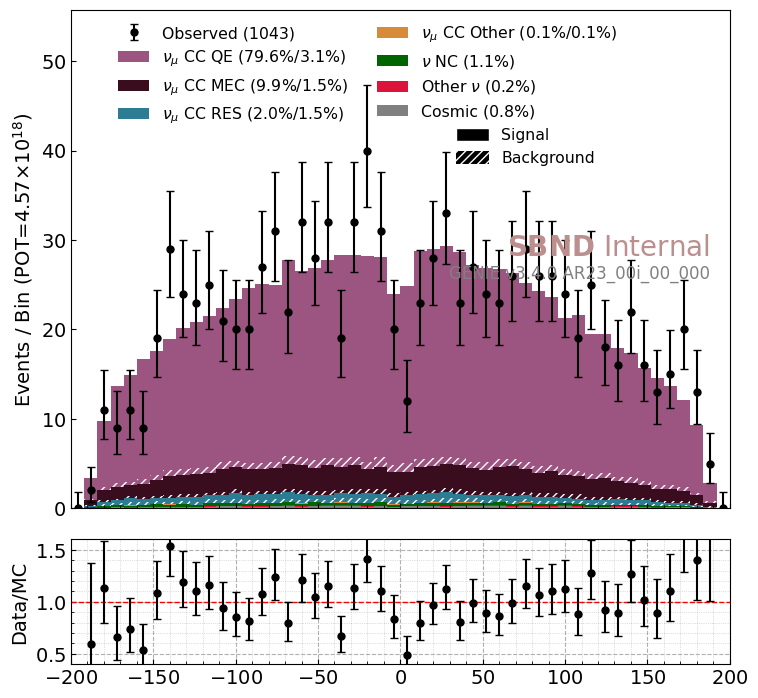

No dirt cosmics provided


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:610: RuntimeWarning: invalid value encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:611: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(data_ratio, nan=-999.)
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:612: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)


no syst provided


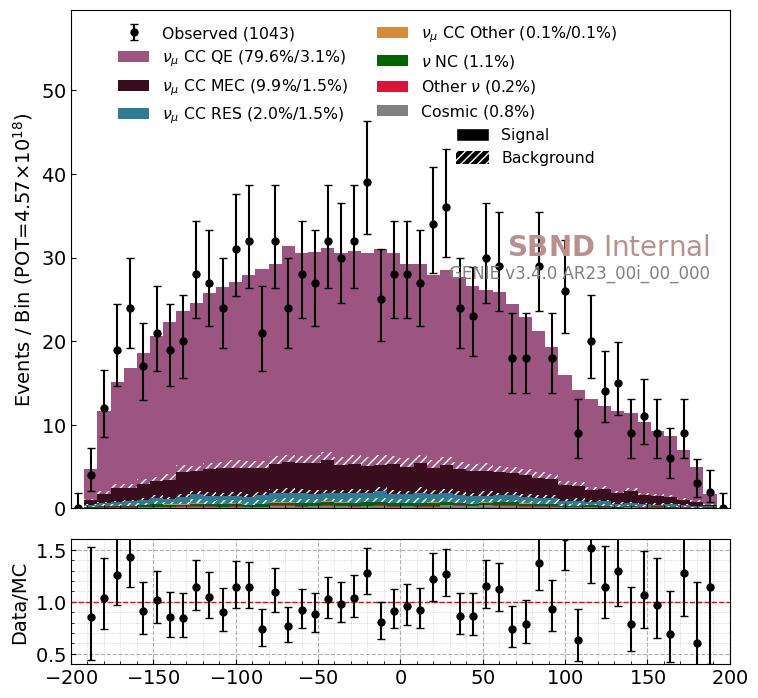

No dirt cosmics provided


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:610: RuntimeWarning: invalid value encountered in divide
  data_ratio_eyhigh = data_eyhigh / total_mc
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:611: RuntimeWarning: divide by zero encountered in divide
  data_ratio = np.nan_to_num(data_ratio, nan=-999.)
/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/utils.py:612: RuntimeWarning: divide by zero encountered in divide
  data_ratio_eylow = np.nan_to_num(data_ratio_eylow, nan=0.)


no syst provided


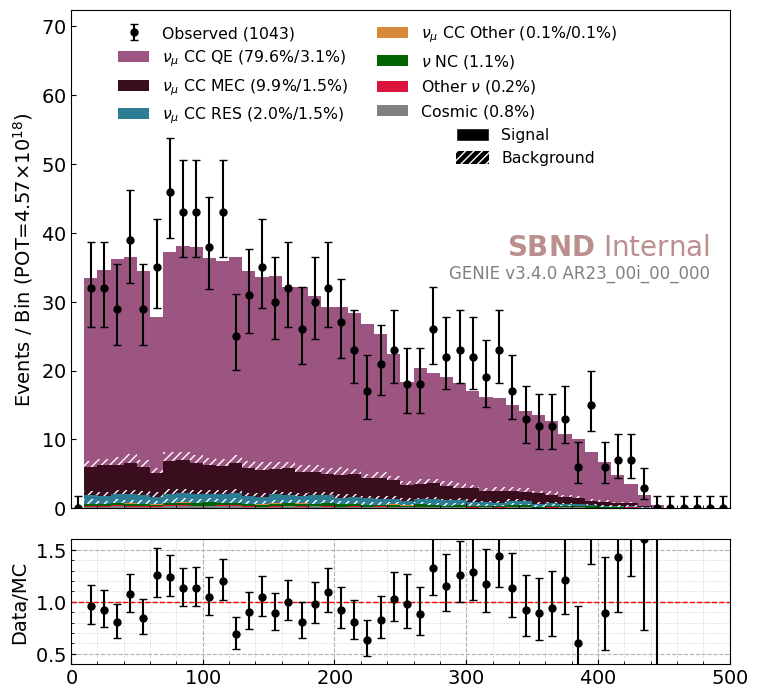

In [134]:
var_configs = [
    VariableConfig.muon_direction_x(),
    VariableConfig.muon_direction_y(),
    VariableConfig.muon_direction_phi(),
    VariableConfig.proton_direction_x(),
    VariableConfig.proton_direction_y(),
    VariableConfig.proton_direction_phi(),
    VariableConfig.vertex_x(),
    VariableConfig.vertex_y(),
    VariableConfig.vertex_z(),
    ]

for var_config in var_configs:

    plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

    # for breakdown_type in ["topology", "genie", "genie_sb"]:
    for breakdown_type in ["genie_sb"]:
        ret = data_vs_mc_plotter(breakdown_type=breakdown_type,
                                var_config=var_config,
                                plot_labels=plot_labels_hist,
                                syst=None,
                                save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

In [ ]:
var_config = VariableConfig.neutrino_energy()
plot_labels_hist = [var_config.var_labels[1], pot_label, ""]

for breakdown_type in ["topology", "genie"]:
    ret = overlay_hists(breakdown_type=breakdown_type,
                        mc_df=mc_evt_df,
                        data_df=None,
                        intime_df=None,
                        dirt_df=None,
                        var_config=var_config,
                        plot_labels=plot_labels_hist,
                        ax_ylim_ratio=1.4,
                        ratio=False,
                        syst=None,
                        textloc=textloc,
                        approval=approval,
                        save_fig=save_fig, 
                        save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# Position Breakdown

In [ ]:
def position_mask(df):
    return (df.slc.vertex.z > 20) & (df.slc.vertex.z < 100)

breakdown_type = "topology"
ret = overlay_hists(breakdown_type=breakdown_type,
                    mc_df=mc_evt_df[position_mask(mc_evt_df)],
                    data_df=data_evt_df[position_mask(data_evt_df)],
                    intime_df=intime_evt_df[position_mask(intime_evt_df)],
                    var_config=var_config,
                    plot_labels=plot_labels_hist,
                    ax_ylim_ratio=ax_ylim_ratio,
                    ratio=ratio,
                    syst=syst,
                    textloc=textloc,
                    approval=approval,
                    save_fig=save_fig, 
                    save_name=path.join(save_fig_dir, "{}_{}".format(var_config.var_save_name, breakdown_type)))

# Get selected event metadata for hand scanning

In [ ]:
save_meta = False

if save_meta:
    colnames = ["run", "subrun", "evt"]

    topo_categ = get_topo_category(mc_evt_df)
    print(mc_evt_df.topo_categ.value_counts())

    # ===== MC =====
    # signal
    signal_meta = mc_hdr_df.loc[topo_categ[topo_categ == 1].reset_index(level=[2]).index][colnames]
    signal_meta.to_csv("signal_meta.csv", index=False)

    # cosmic
    cosmic_meta = mc_hdr_df.loc[topo_categ[topo_categ == -1].reset_index(level=[2]).index][colnames]
    cosmic_meta.to_csv("cosmic_meta.csv", index=False)

    # nu out of FV
    nu_outfv_meta = mc_hdr_df.loc[topo_categ[topo_categ == 0].reset_index(level=[2]).index][colnames]
    nu_outfv_meta.to_csv("nu_outfv_meta.csv", index=False)

    # numu cc np0pi
    numucc_np0pi_meta = mc_hdr_df.loc[topo_categ[topo_categ == 2].reset_index(level=[2]).index][colnames]
    numucc_np0pi_meta.to_csv("numucc_np0pi_meta.csv", index=False)

    # numu cc other
    numucc_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 3].reset_index(level=[2]).index][colnames]
    numucc_other_meta.to_csv("numucc_other_meta.csv", index=False)

    # numu nc
    numucc_nc_meta = mc_hdr_df.loc[topo_categ[topo_categ == 4].reset_index(level=[2]).index][colnames]
    numucc_nc_meta.to_csv("numucc_nc_meta.csv", index=False)

    # nu other
    nu_other_meta = mc_hdr_df.loc[topo_categ[topo_categ == 5].reset_index(level=[2]).index][colnames]
    nu_other_meta.to_csv("nu_other_meta.csv", index=False)

    # ===== Data =====
    data_meta = data_hdr_df.loc[data_evt_df.reset_index(level=[2]).index][colnames]
    data_meta.to_csv("data_meta.csv", index=False)

# True Topology Breakdown of Selected Events

In [ ]:
mc_evt_df

In [ ]:
# get unique combinations of final state topologies 
# and count how many events have each combination

# this_df = mc_evt_df[IsNuInFV_NumuCC_Np0pi(mc_evt_df)]
# this_df = mc_evt_df[IsNuInFV_NumuCC_Other(mc_evt_df)]
this_df = mc_evt_df.mc.copy()

particle_list = ["nmu_220MeVc", "np_300MeVc", "npi_70MeVc", "npi0"]
unique_fs = this_df[particle_list].drop_duplicates().dropna()
unique_fs_list = []
for i in unique_fs.index:
    this_fs = []
    for particle in particle_list:
        this_n_val = unique_fs.loc[i][particle].values[0]
        this_fs.append(int(this_n_val))
    unique_fs_list.append(this_fs)
print(len(unique_fs_list), "unique final state combinations")

# count how many events have each combination
n_list = []
perc_list = []
for uc in unique_fs_list:
    for pidx, particle in enumerate(particle_list):
        if pidx == 0:
            fs_mask = (this_df[particle] == uc[pidx]) 
        else:
            fs_mask = fs_mask & (this_df[particle] == uc[pidx])
    this_type_n = len(this_df[fs_mask])
    n_mc_tot = len(mc_evt_df) * mc_evt_df.pot_weight.unique()[0]
    n_intime_tot = len(intime_evt_df) * intime_evt_df.pot_weight.unique()[0]
    n_dirt_tot = len(dirt_evt_df) * dirt_evt_df.pot_weight.unique()[0]
    # this_type_perc = this_type_n * mc_evt_df.pot_weight.unique()[0] / (n_mc_tot + n_intime_tot + n_dirt_tot)
    this_type_perc = this_type_n * mc_evt_df.pot_weight.unique()[0] / (n_mc_tot + n_intime_tot + n_dirt_tot)
    n_list.append(this_type_n)
    perc_list.append(this_type_perc)
    print(uc, this_type_perc*100, this_type_n)

print(sum(perc_list))